In [126]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve
)

from imblearn.over_sampling import RandomOverSampler

sns.set_theme(style="whitegrid")

In [127]:
class Dataset:

    def __init__(self, filepath):

        self.filepath = filepath
        self.df = None

    def load(self):

        self.df = pd.read_csv(self.filepath)

        print("="*40)
        print("DATASET BERHASIL DIMUAT")
        print("="*40)
        print("Shape :", self.df.shape)

        return self.df

    def head(self, n=5):

        return self.df.head(n)

    def info(self):

        return self.df.info()

    def missing_values(self):

        return self.df.isnull().sum()

    def churn_distribution(self):

        distribution = (
            self.df["Exited"]
            .value_counts(normalize=True)
            *100
        )

        return distribution

In [128]:
class Preprocessor:

    def __init__(self, df):

        self.df = df.copy()

        self.X = None
        self.y = None

        self.X_train = None
        self.X_test = None

        self.y_train = None
        self.y_test = None

        self.scaler = None
        self.ros = None

        self.X_train_scaled = None
        self.X_test_scaled = None

    def clean_data(self):

        self.df = self.df.drop(
            columns=[
                "RowNumber",
                "CustomerId",
                "Surname"
            ]
        )

        self.df = pd.get_dummies(
            self.df,
            columns=[
                "Geography",
                "Gender"
            ],
            drop_first=True
        )

        for col in self.df.columns:

            if self.df[col].dtype == bool:

                self.df[col] = self.df[col].astype(int)

        print("="*40)
        print("DATA BERHASIL DIBERSIHKAN")
        print("="*40)

        return self.df


    def random_oversampling(self):

        self.X = self.df.drop(
            "Exited",
            axis=1
        )

        self.y = self.df["Exited"]

        self.ros = RandomOverSampler(

            sampling_strategy=1.0,
            random_state=42

        )

        self.X, self.y = self.ros.fit_resample(

            self.X,
            self.y

        )

        print("="*40)
        print("RANDOM OVER SAMPLING")
        print("="*40)

        print(self.y.value_counts())

        return self.X, self.y


    def split(self):

        (
            self.X_train,
            self.X_test,
            self.y_train,
            self.y_test

        ) = train_test_split(

            self.X,
            self.y,

            test_size=0.20,
            random_state=42,
            stratify=self.y

        )

        print("="*40)
        print("TRAIN TEST SPLIT")
        print("="*40)

        print("\nTraining")
        print(self.y_train.value_counts())

        print("\nTesting")
        print(self.y_test.value_counts())

        return (

            self.X_train,
            self.X_test,
            self.y_train,
            self.y_test

        )


    def scale(self):

        self.scaler = StandardScaler()

        self.X_train_scaled = self.scaler.fit_transform(
            self.X_train
        )

        self.X_test_scaled = self.scaler.transform(
            self.X_test
        )

        print("="*40)
        print("STANDARD SCALER")
        print("="*40)

        return (

            self.X_train_scaled,
            self.X_test_scaled

        )

In [129]:
class LogisticRegressionModel:

    def __init__(self):

        self.model = LogisticRegression(
            random_state=42,
            max_iter=1000
        )

        self.y_pred = None
        self.y_prob = None
        self.z_score = None

    def fit(
        self,
        X_train,
        y_train
    ):

        self.model.fit(
            X_train,
            y_train
        )

        print("="*40)
        print("MODEL BERHASIL DILATIH")
        print("="*40)

        return self

    def predict(
        self,
        X_test
    ):

        self.y_pred = (
            self.model.predict(
                X_test
            )
        )

        self.y_prob = (
            self.model.predict_proba(
                X_test
            )[:,1]
        )

        self.z_score = (
            self.model.decision_function(
                X_test
            )
        )

        return (

            self.y_pred,
            self.y_prob,
            self.z_score

        )

    def coefficients(
        self,
        feature_names
    ):

        coef_df = pd.DataFrame({

            "Feature": feature_names,

            "Coefficient":
            self.model.coef_[0]

        })

        coef_df["Importance"] = (
            coef_df["Coefficient"]
            .abs()
        )

        coef_df = coef_df.sort_values(

            by="Importance",
            ascending=False

        )

        return coef_df

    def odds_ratio(
        self,
        feature_names
    ):

        odds_df = pd.DataFrame({

            "Feature": feature_names,

            "Odds Ratio":
            np.exp(
                self.model.coef_[0]
            )

        })

        odds_df = odds_df.sort_values(

            by="Odds Ratio",
            ascending=False

        )

        return odds_df

    def intercept(self):

        return self.model.intercept_[0]

    def summary(
        self,
        feature_names
    ):

        summary_df = pd.DataFrame({

            "Feature":
            feature_names,

            "Coefficient":
            self.model.coef_[0],

            "Odds Ratio":
            np.exp(
                self.model.coef_[0]
            ),

            "Importance":
            np.abs(
                self.model.coef_[0]
            )

        })

        summary_df = summary_df.sort_values(

            by="Importance",
            ascending=False

        )

        return summary_df

In [130]:
class Evaluation:

    @staticmethod
    def metrics(
        y_true,
        y_pred
    ):

        metric_df = pd.DataFrame({

            "Metric":[

                "Accuracy",
                "Precision",
                "Recall",
                "F1 Score"

            ],

            "Value":[

                accuracy_score(
                    y_true,
                    y_pred
                ),

                precision_score(
                    y_true,
                    y_pred
                ),

                recall_score(
                    y_true,
                    y_pred
                ),

                f1_score(
                    y_true,
                    y_pred
                )

            ]

        })

        return metric_df

    @staticmethod
    def report(
        y_true,
        y_pred
    ):

        return classification_report(

            y_true,
            y_pred

        )

    @staticmethod
    def confusion(
        y_true,
        y_pred
    ):

        return confusion_matrix(

            y_true,
            y_pred

        )

    @staticmethod
    def evaluate(
        y_true,
        y_pred
    ):

        print("="*50)
        print("HASIL EVALUASI MODEL")
        print("="*50)

        metric = Evaluation.metrics(
            y_true,
            y_pred
        )

        print(metric)

        print("\n")

        print("="*50)
        print("CLASSIFICATION REPORT")
        print("="*50)

        print(

            Evaluation.report(
                y_true,
                y_pred
            )

        )

        print("="*50)

        cm = Evaluation.confusion(
            y_true,
            y_pred
        )

        return metric, cm

    @staticmethod
    def probability_table(
        y_test,
        y_pred,
        y_prob,
        z_score
    ):

        result = pd.DataFrame({

            "Actual":

            y_test.reset_index(
                drop=True
            ),

            "Prediction":

            y_pred,

            "Probability":

            np.round(
                y_prob,
                4
            ),

            "Z Score":

            np.round(
                z_score,
                4
            )

        })

        return result

In [131]:
class Visualization:

    @staticmethod
    def show_all(
        df,
        z_score,
        y_prob,
        y_test,
        cm,
        coef_df
    ):

        plt.figure(figsize=(6,4))

        sns.countplot(
            data=df,
            x="Exited",
            palette="Blues"
        )

        plt.title(
            "Customer Churn Distribution",
            fontsize=14,
            fontweight="bold"
        )

        plt.xlabel("Exited")
        plt.ylabel("Count")

        plt.tight_layout()
        plt.show()

        # 2. Sigmoid Function

        z = np.linspace(-10,10,1000)

        sigmoid = 1/(1+np.exp(-z))

        plt.figure(figsize=(7,5))

        plt.plot(
            z,
            sigmoid,
            linewidth=2
        )

        plt.title(
            "Sigmoid Function",
            fontsize=14,
            fontweight="bold"
        )

        plt.xlabel("Z Score")
        plt.ylabel("Probability")

        plt.grid(True)

        plt.tight_layout()
        plt.show()

        plt.figure(figsize=(7,5))

        plt.scatter(

            z_score,
            y_prob,

            alpha=0.45

        )

        plt.title(
            "Sigmoid Transformation",
            fontsize=14,
            fontweight="bold"
        )

        plt.xlabel("Decision Score (Z)")
        plt.ylabel("Predicted Probability")

        plt.grid(True)

        plt.tight_layout()
        plt.show()

        plt.figure(figsize=(6,5))

        sns.heatmap(

            cm,

            annot=True,

            fmt="d",

            cmap="Blues",

            xticklabels=[
                "No Churn",
                "Churn"
            ],

            yticklabels=[
                "No Churn",
                "Churn"
            ]

        )

        plt.title(
            "Confusion Matrix",
            fontsize=14,
            fontweight="bold"
        )

        plt.xlabel("Predicted Label")
        plt.ylabel("Actual Label")

        plt.tight_layout()
        plt.show()

        precision_curve, recall_curve, _ = (

            precision_recall_curve(

                y_test,
                y_prob

            )

        )

        plt.figure(figsize=(7,5))

        plt.plot(

            recall_curve,
            precision_curve,

            linewidth=2

        )

        plt.title(
            "Precision Recall Curve",
            fontsize=14,
            fontweight="bold"
        )

        plt.xlabel("Recall")
        plt.ylabel("Precision")

        plt.grid(True)

        plt.tight_layout()
        plt.show()

        coef_df = coef_df.sort_values(
            by="Coefficient"
        )

        plt.figure(figsize=(10,6))

        sns.barplot(

            data=coef_df,

            x="Coefficient",

            y="Feature",

            palette="viridis"

        )

        plt.axvline(
            x=0,
            color="black",
            linestyle="--"
        )

        plt.title(
            "Feature Coefficients",
            fontsize=14,
            fontweight="bold"
        )

        plt.xlabel("Coefficient")
        plt.ylabel("Feature")

        plt.tight_layout()
        plt.show()

        plt.figure(figsize=(7,5))

        plt.hist(

            y_prob,

            bins=30,

            edgecolor="black"

        )

        plt.title(
            "Predicted Probability Distribution",
            fontsize=14,
            fontweight="bold"
        )

        plt.xlabel("Probability")
        plt.ylabel("Frequency")

        plt.tight_layout()
        plt.show()

        plt.figure(figsize=(7,5))

        plt.hist(

            z_score,

            bins=30,

            edgecolor="black"

        )

        plt.title(
            "Decision Score Distribution",
            fontsize=14,
            fontweight="bold"
        )

        plt.xlabel("Decision Score")
        plt.ylabel("Frequency")

        plt.tight_layout()
        plt.show()

DATASET BERHASIL DIMUAT
Shape : (10000, 14)

===== 5 DATA PERTAMA =====
   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   
3       1       0.00              2          0               0   
4       2  125510.82              1          1               1   

   EstimatedSalary  Exited  
0        101348.88       1  
1        112542.58       0  

C:\Users\Kimi Thora\AppData\Local\Temp\ipykernel_20088\3547963400.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


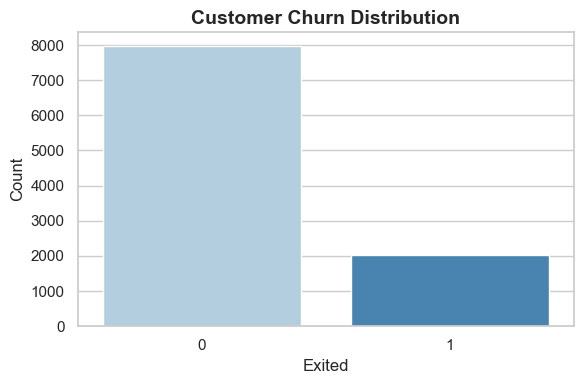

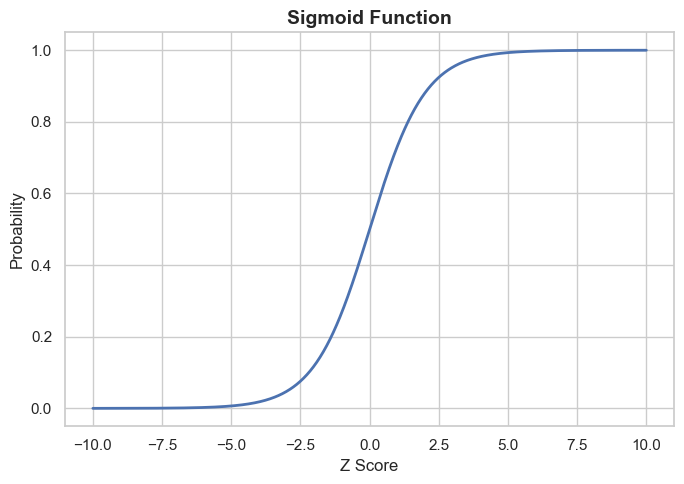

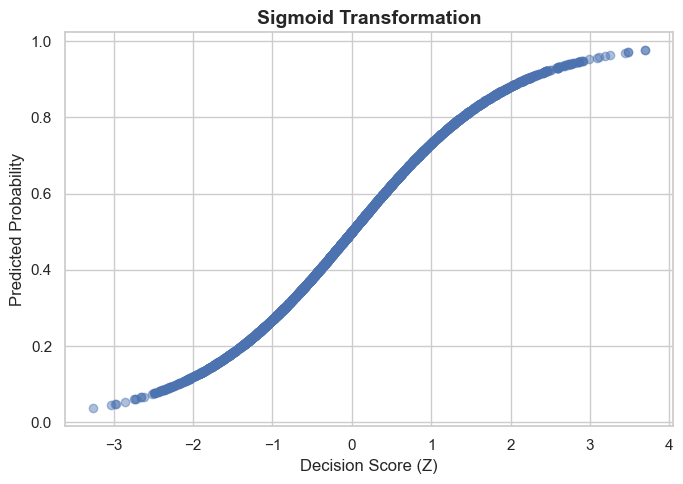

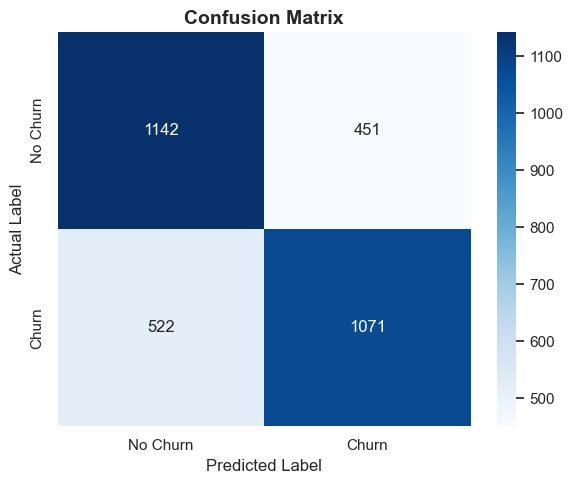

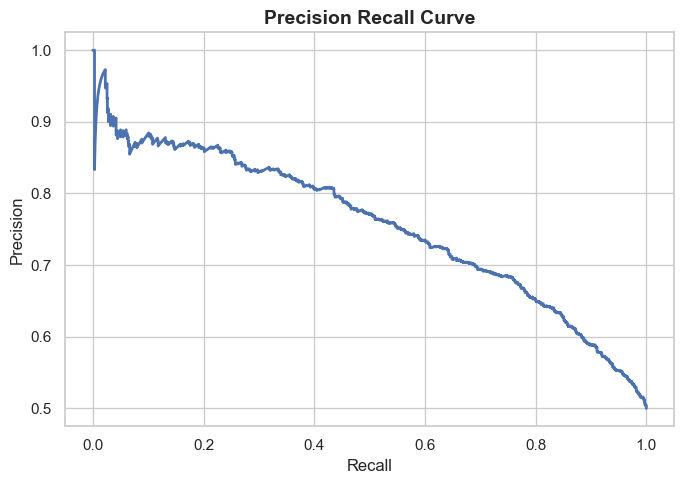

C:\Users\Kimi Thora\AppData\Local\Temp\ipykernel_20088\3547963400.py:164: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


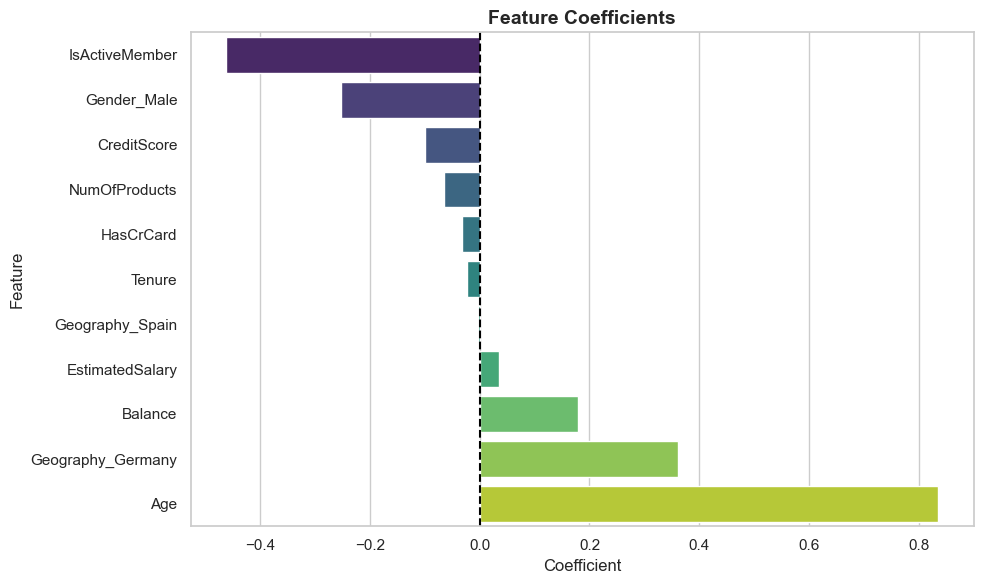

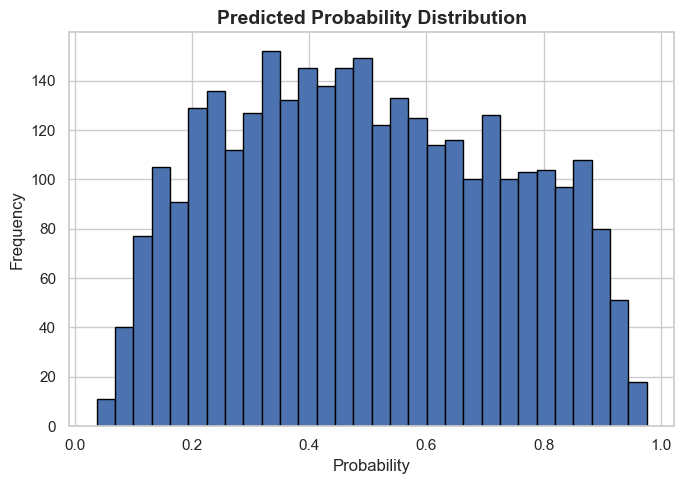

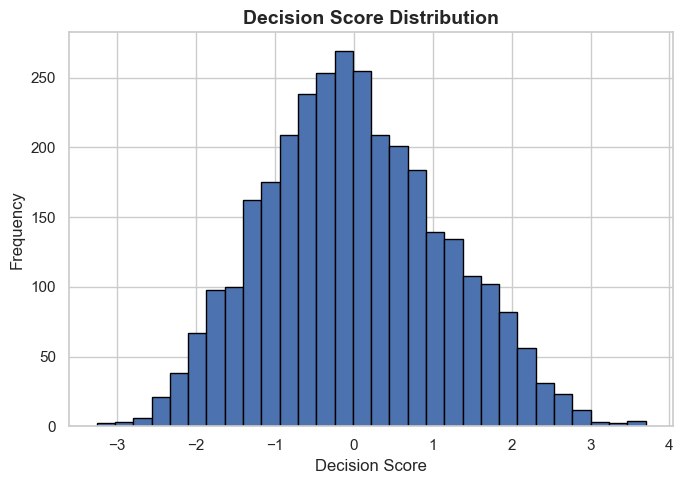



PROGRAM SELESAI


In [132]:
if __name__ == "__main__":

    # =====================================================
    # 1. Load Dataset
    # =====================================================

    dataset = Dataset("Churn_Modelling.csv")

    df = dataset.load()

    print("\n===== 5 DATA PERTAMA =====")
    print(dataset.head())

    print("\n===== MISSING VALUES =====")
    print(dataset.missing_values())

    print("\n===== DISTRIBUSI CHURN (%) =====")
    print(dataset.churn_distribution())

    # =====================================================
    # 2. Data Preprocessing
    # =====================================================

    prep = Preprocessor(df)

    prep.clean_data()

    # Random Oversampling
    prep.random_oversampling()

    # Train Test Split
    prep.split()

    # Standardisasi
    prep.scale()

    # =====================================================
    # 3. Training Logistic Regression
    # =====================================================

    model = LogisticRegressionModel()

    model.fit(
        prep.X_train_scaled,
        prep.y_train
    )

    (
        y_pred,
        y_prob,
        z_score
    ) = model.predict(
        prep.X_test_scaled
    )

    # =====================================================
    # 4. Informasi Model
    # =====================================================

    print("\n")
    print("=" * 60)
    print("INTERCEPT")
    print("=" * 60)
    print(model.intercept())

    coef_df = model.coefficients(
        prep.X.columns
    )

    odds_df = model.odds_ratio(
        prep.X.columns
    )

    summary_df = model.summary(
        prep.X.columns
    )

    print("\n")
    print("=" * 60)
    print("COEFFICIENT")
    print("=" * 60)
    print(coef_df)

    print("\n")
    print("=" * 60)
    print("ODDS RATIO")
    print("=" * 60)
    print(odds_df)

    print("\n")
    print("=" * 60)
    print("SUMMARY")
    print("=" * 60)
    print(summary_df)

    # =====================================================
    # 5. Evaluasi
    # =====================================================

    metric_df = Evaluation.metrics(
        prep.y_test,
        y_pred
    )

    report = Evaluation.report(
        prep.y_test,
        y_pred
    )

    cm = Evaluation.confusion(
        prep.y_test,
        y_pred
    )

    print("\n")
    print("=" * 60)
    print("METRICS")
    print("=" * 60)
    print(metric_df)

    print("\n")
    print("=" * 60)
    print("CLASSIFICATION REPORT")
    print("=" * 60)
    print(report)

    print("\n")
    print("=" * 60)
    print("CONFUSION MATRIX")
    print("=" * 60)
    print(pd.DataFrame(cm))

    probability_df = Evaluation.probability_table(
        prep.y_test,
        y_pred,
        y_prob,
        z_score
    )

    print("\n")
    print("=" * 60)
    print("PREDICTION RESULT")
    print("=" * 60)
    print(probability_df.head(20))

    # =====================================================
    # 6. Visualisasi
    # =====================================================

    Visualization.show_all(
        prep.df,
        z_score,
        y_prob,
        prep.y_test,
        cm,
        coef_df
    )

    print("\n")
    print("=" * 60)
    print("PROGRAM SELESAI")
    print("=" * 60)